# Multiple Choice Question Evaluation for Zeolite Synthesis

Run with kernel v6 instead of v7

This notebook evaluates an LLM's performance on multiple-choice questions about zeolite synthesis by comparing generated answers with ground truth.

In [1]:
# Core imports
import os
import torch
import json
import pandas as pd
from datetime import datetime
from tqdm import tqdm

# LangChain and Transformers
from langchain.prompts import ChatPromptTemplate
from langchain.llms import HuggingFacePipeline
from langchain.chains import LLMChain
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

# GPU setup
os.environ["CUDA_VISIBLE_DEVICES"] = "3"
torch.cuda.set_device(0)

In [2]:
!nvidia-smi

Fri Feb 13 14:55:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.119.02             Driver Version: 580.119.02     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A5000               Off |   00000000:31:00.0 Off |                  Off |
| 30%   40C    P0             67W /  230W |       4MiB /  24564MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
!kill -9 2851800 

/bin/bash: line 0: kill: (2851800) - No such process


In [4]:
# Initialize the model
model_name = "mistralai/Mistral-7B-Instruct-v0.1"

# Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(
    model_name, 
    trust_remote_code=True, 
    use_fast=False
)

model = AutoModelForCausalLM.from_pretrained(
    model_name, 
    device_map="auto", 
    trust_remote_code=True,
    torch_dtype=torch.float16
)

# Set up pipeline
pipe = pipeline("text-generation", model=model, tokenizer=tokenizer, max_length=2000)
llm = HuggingFacePipeline(pipeline=pipe)

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

/tmp/ipykernel_1982820/3692147747.py:20: LangChainDeprecationWarning: The class `HuggingFacePipeline` was deprecated in LangChain 0.0.37 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFacePipeline``.
  llm = HuggingFacePipeline(pipeline=pipe)


In [5]:
# Multiple choice prompt template
MC_PROMPT = """
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
{context}

Question: {question}

Provide your answer in the following format EXACTLY:
Answer: [LETTER] - [One sentence explanation]

For example:
Answer: B - The synthesis temperature was increased to improve crystallization.

Choose only from options A, B, C, D, or E."""

In [6]:
def evaluate_mc_response(query, correct_answer, context):
    """Evaluate a single multiple choice question."""
    mc_prompt = ChatPromptTemplate.from_template(MC_PROMPT)
    chain = LLMChain(llm=llm, prompt=mc_prompt)
    
    try:
        # Get model's answer
        full_response = chain.run(context=context, question=query)
        
        # Debug print
        print(f"Raw response: '{full_response}'")
        
        # Find the last occurrence of "Answer: " (to avoid the example)
        last_answer_pos = full_response.rfind("Answer: ")
        
        if last_answer_pos != -1:
            # Get the character right after "Answer: "
            model_answer = full_response[last_answer_pos + 8].upper()
            
            if model_answer in ['A', 'B', 'C', 'D', 'E']:
                # Try to get explanation if available
                explanation = ""
                answer_end = full_response[last_answer_pos:].split('\n')[0]  # Get just the answer line
                if '-' in answer_end:
                    explanation = answer_end.split('-', 1)[1].strip()
                
                return {
                    'query': query,
                    'context': context,
                    'model_answer': model_answer,
                    'correct_answer': correct_answer,
                    'is_correct': model_answer == correct_answer,
                    'full_response': full_response,
                    'explanation': explanation
                }
        
        # If we get here, no valid answer was found
        return {
            'query': query,
            'context': context,
            'model_answer': 'INVALID',
            'correct_answer': correct_answer,
            'is_correct': False,
            'error': f"No valid answer found in response"
        }
        
    except Exception as e:
        print(f"Processing error: {str(e)}")
        return {
            'query': query,
            'context': context,
            'model_answer': 'INVALID',
            'correct_answer': correct_answer,
            'is_correct': False,
            'error': f"Error processing response: {str(e)}"
        }

In [7]:
# Main evaluation
# Read the Synthesis sheet
synthesis_df = pd.read_excel('questionbank(unedited).xlsx', sheet_name='Synthesis')

# Remove rows with blank questions
synthesis_df = synthesis_df.dropna(subset=['gpt_generated_question'])

print(f"Total questions (after removing blanks): {len(synthesis_df)}")

# Process each question
results = []
correct_count = 0

for idx, row in tqdm(synthesis_df.iterrows(), total=len(synthesis_df), desc="Evaluating questions"):
    context = row['abstract']
    question = row['gpt_generated_question']
    correct_answer = row['gpt_generated_answer'].strip().upper()
    
    # Evaluate the question
    result = evaluate_mc_response(question, correct_answer, context)
    results.append(result)
    
    # Update count and show progress
    if result['is_correct']:
        correct_count += 1
    
    # Show immediate feedback
    print(f"\nQuestion {idx + 1}:")
    print(f"Model's answer: {result['model_answer']}")
    if 'explanation' in result:
        print(f"Explanation: {result['explanation']}")
    print(f"Correct answer: {correct_answer}")
    print(f"Current accuracy: {(correct_count / (idx + 1)) * 100:.2f}%")

# Calculate final accuracy
final_accuracy = (correct_count / len(synthesis_df)) * 100

# Print summary
print("\n=== Final Results ===")
print(f"Total questions: {len(synthesis_df)}")
print(f"Correct answers: {correct_count}")
print(f"Final accuracy: {final_accuracy:.2f}%")

# Save detailed results
output_filename = f"mc_evaluation_results_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
with open(output_filename, 'w') as f:
    json.dump({
        'summary': {
            'total_questions': len(synthesis_df),
            'correct_answers': correct_count,
            'accuracy': final_accuracy
        },
        'detailed_results': results
    }, f, indent=2)

print(f"\nDetailed results saved to: {output_filename}")

Total questions (after removing blanks): 39


Evaluating questions:   0%|          | 0/39 [00:00<?, ?it/s]/tmp/ipykernel_1982820/4103750729.py:4: LangChainDeprecationWarning: The class `LLMChain` was deprecated in LangChain 0.1.17 and will be removed in 1.0. Use :meth:`~RunnableSequence, e.g., `prompt | llm`` instead.
  chain = LLMChain(llm=llm, prompt=mc_prompt)
/tmp/ipykernel_1982820/4103750729.py:8: LangChainDeprecationWarning: The method `Chain.run` was deprecated in langchain 0.1.0 and will be removed in 1.0. Use :meth:`~invoke` instead.
  full_response = chain.run(context=context, question=query)
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Evaluating questions:   3%|▎         | 1/39 [00:05<03:21,  5.29s/it]Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
Two-layered H-ZSM-5-mordenite membranes have been prepared on alumina tubular supports. The objective of this work is to merge the catalytic activity of H-ZSM-5 with the pervaporation water selectivity of mordenite membranes, i.e. to produce true bi-functional zeolite membranes. To be sure that the needed thermal treatment (to remove TPAOH template from the H-ZSM-5 pores) stage did not alter the hydrophilic character of these two-layered H-ZSM-5-mordenite membranes, the calcination was carried out under a steam/air atmosphere. Experiments concerning the pervaporation of water/ethanol mixtures and the esterification of acetic acid with ethanol were performed to demonstrate the applicability of the membranes prepared here.

Question: What is t

Evaluating questions:   5%|▌         | 2/39 [00:06<01:55,  3.12s/it]Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
We have used a dual template synthesis method based on an initial ZSM-5 zeolite sol precursor in the presence of molecular and micellar templates to obtain X-ray amorphous and zeolite-containing microporous/mesoporous aluminosilicates having an ordered MCM-41 mesostructure, extended mesoporosity, small micropore volume, and medium-strength acid sites. We note a deviation from additivity for the change in micropore volume and the concentration of acid sites in the synthesized zeolitized samples.

Question: What is a key characteristic of materials synthesized using a dual template method involving both molecular and micellar templates?
A) They typically exhibit only microporous structures.
B) They are limited to having weak acid sites.
C) The

...

Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
Hierarchical SAPO-34 zeolites with three-dimensionally ordered mesoporous-imprinted structure (3DOm-i SAPO-34) were first confined synthesized within three-dimensionally ordered mesoporous carbons by multiple hydrothermal (MHT) treatments. With perfect structure replication, the obtained 3DOm-i SAPO-34 zeolite particles exhibited unique ordered structures consisting of primary spherical elements of sizes determined by mesopore cages of the corresponding carbon templates, and the sizes of mesopores constituted by the adjacent spherical elements can be precisely tuned from 5.5 to 13.0nm by varying the 3DOm carbon. The as-synthesized hierarchical 3DOm-i SAPO-34 catalysts showed superior catalytic performance in the MTO reaction with prolonged c

Evaluating questions:  97%|█████████▋| 38/39 [01:02<00:01,  2.00s/it]/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
Earlier, we reported prior dealumination of Y zeolite provides much higher activity and selectivity for the ammoxidation of ethane to acetonitrile. In this manuscript, we describe the preparation of active dealuminated Y catalysts by both aqueous and solid-state ion-exchange procedures. Although it is difficult to achieve exactly the same levels of exchange by these two techniques, in general solid state exchange of cobalt ion resulted in less cobalt in the exchange sites, but higher yields of acetonitrile at lower Co/Al values. Solid-state exchange of three different zeolite topologies (ZSM-5, beta, and USY) also produced enhanced selectivity for NH3 incorporation into acetonitrile.

Question: What is the effect of dealumination on the acti

Evaluating questions: 100%|██████████| 39/39 [01:03<00:00,  1.63s/it]

Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
Studies in the past decade suggest that microwave energy may have a unique ability to influence chemical processes. These include chemical and materials syntheses as well as separations. Specifically, recent studies have documented significantly reduced time for the fabrication of zeolites employing microwave energy. However, the mechanism and engineering for the enhanced rates of syntheses are unknown. The results from different laboratories are not consistent, and experimental details are sparse. We studied the synthesis of silicalite employing two geometries in an oven with 2.45-GHz microwaves. The distribution of microwave energies within the reactors from simulation differed, and the morphologies and yields of the resultant zeolite also

# Comparative Evaluation: Different Context Sources

Now we'll compare the LLM's accuracy across different context retrieval methods:
1. **Abstract as context** (baseline - already computed above)
2. **No context** - Pure LLM knowledge
3. **FAISS only** - Semantic similarity search (k=10)
4. **MMR only** - Maximum Marginal Relevance search (k=10)
5. **BM25 only** - Keyword-based retrieval (k=10)
6. **Hybrid (MMR + BM25)** - Combined retrieval (k=10)
7. **LLM-Optimized Query** - Query optimization + FAISS retrieval (k=10)

In [8]:
# Load the vector database and retrieval components from Mrigi 21
from langchain.embeddings import SentenceTransformerEmbeddings
from langchain.vectorstores import FAISS
from langchain.retrievers import BM25Retriever
from pathlib import Path

# Initialize embeddings (same as Mrigi 21)
embeddings = SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2")

# Load FAISS index
INDEX_DIRECTORY = Path("faiss_index")
INDEX_NAME = "index"

if not INDEX_DIRECTORY.exists():
    raise FileNotFoundError(f"Vector index directory '{INDEX_DIRECTORY}' not found.")

vector_db = FAISS.load_local(
    INDEX_DIRECTORY,
    embeddings,
    index_name=INDEX_NAME,
    allow_dangerous_deserialization=True
)
print(f"✓ Loaded vector database from {INDEX_DIRECTORY} with {vector_db.index.ntotal} vectors")

# Get all documents for BM25
all_docs = vector_db.similarity_search("", k=vector_db.index.ntotal)
bm25_retriever = BM25Retriever.from_documents(all_docs)
bm25_retriever.k = 10
print(f"✓ Initialized BM25 retriever with {len(all_docs)} documents")

/tmp/ipykernel_1982820/2636707329.py:8: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2")


✓ Loaded vector database from faiss_index with 1474439 vectors
✓ Initialized BM25 retriever with 1474439 documents


In [9]:
# Define hybrid search function (from Mrigi 21)
def hybrid_search(query, vector_db, bm25_retriever, k_total=10, k_bm25=10, k_mmr=10, 
                  mmr_fetch_k=40, mmr_lambda=0.6):
    """
    Hybrid retrieval combining BM25 and MMR results.
    
    Args:
        query: Search query string
        vector_db: FAISS vector store
        bm25_retriever: BM25 retriever instance
        k_total: Total number of documents to return (default=10)
        k_bm25: Number of documents to retrieve from BM25 (default=10)
        k_mmr: Number of documents to retrieve from MMR (default=10)
        mmr_fetch_k: Candidate pool size for MMR (default=40)
        mmr_lambda: Diversity parameter for MMR (default=0.6)
    
    Returns:
        List of unique documents
    """
    # Get BM25 results
    bm25_retriever.k = k_bm25
    bm25_docs = bm25_retriever.get_relevant_documents(query)
    
    # Get MMR results
    mmr_docs = vector_db.max_marginal_relevance_search(
        query,
        k=k_mmr,
        fetch_k=mmr_fetch_k,
        lambda_mult=mmr_lambda
    )
    
    # Combine and deduplicate
    seen_content = set()
    combined_docs = []
    
    for doc in bm25_docs + mmr_docs:
        content_hash = hash(doc.page_content)
        if content_hash not in seen_content:
            seen_content.add(content_hash)
            combined_docs.append(doc)
            if len(combined_docs) >= k_total:
                break
    
    return combined_docs

print("✓ Hybrid search function defined")

✓ Hybrid search function defined


In [10]:
# Define LLM query optimizer function (adapted from Mrigi 21 for MCQ context)
def optimize_query_for_mcq(question: str, llm) -> str:
    """
    Use LLM to convert a multiple choice question into an optimized search query.
    
    Args:
        question: Original MCQ question (with options A-E)
        llm: LangChain LLM instance
    
    Returns:
        Optimized search query string
    """
    QUERY_OPTIMIZER_PROMPT = """You are helping optimize multiple choice questions for academic literature search.
Given a multiple choice question about zeolite synthesis, extract the core scientific concepts and convert it into a concise keyword-based search query.
Focus on the main topic: materials, synthesis methods, characterization techniques, properties, or conditions being asked about.
Remove question phrasing, multiple choice options (A-E), and filler words.
Preserve chemical formulas, abbreviations, and domain-specific terminology.
Output a single line of lowercase keywords in a natural but compact order.
Do not explain or summarize—only output the optimized search query.

Question: {question}

Optimized query:"""
    
    try:
        # Create a simple prompt
        prompt_template = ChatPromptTemplate.from_template(QUERY_OPTIMIZER_PROMPT)
        chain = LLMChain(llm=llm, prompt=prompt_template)
        
        # Generate optimized query
        response = chain.run(question=question)
        
        # Extract only the generated part (after the prompt)
        if "Optimized query:" in response:
            optimized_query = response.split("Optimized query:")[-1].strip()
        else:
            optimized_query = response.strip()
        
        # Clean up any extra text after the first line
        optimized_query = optimized_query.split('\n')[0].strip()
        
        return optimized_query if optimized_query else question  # Fallback to original if empty
    except Exception as e:
        print(f"Error optimizing query: {e}")
        return question  # Fallback to original question on error

print("✓ Query optimizer function defined for MCQ context")

✓ Query optimizer function defined for MCQ context


## Evaluation 1: No Context (Pure LLM Knowledge)

In [11]:
# No context prompt template
NO_CONTEXT_PROMPT = """
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer.

Question: {question}

Provide your answer in the following format EXACTLY:
Answer: [LETTER] - [One sentence explanation]

For example:
Answer: B - The synthesis temperature was increased to improve crystallization.

Choose only from options A, B, C, D, or E."""

def evaluate_mc_no_context(query, correct_answer):
    """Evaluate a single multiple choice question WITHOUT context."""
    no_context_prompt = ChatPromptTemplate.from_template(NO_CONTEXT_PROMPT)
    chain = LLMChain(llm=llm, prompt=no_context_prompt)
    
    try:
        # Get model's answer
        full_response = chain.run(question=query)
        
        # Find the last occurrence of "Answer: "
        last_answer_pos = full_response.rfind("Answer: ")
        
        if last_answer_pos != -1:
            model_answer = full_response[last_answer_pos + 8].upper()
            
            if model_answer in ['A', 'B', 'C', 'D', 'E']:
                explanation = ""
                answer_end = full_response[last_answer_pos:].split('\n')[0]
                if '-' in answer_end:
                    explanation = answer_end.split('-', 1)[1].strip()
                
                return {
                    'query': query,
                    'model_answer': model_answer,
                    'correct_answer': correct_answer,
                    'is_correct': model_answer == correct_answer,
                    'full_response': full_response,
                    'explanation': explanation
                }
        
        return {
            'query': query,
            'model_answer': 'INVALID',
            'correct_answer': correct_answer,
            'is_correct': False,
            'error': f"No valid answer found in response"
        }
        
    except Exception as e:
        print(f"Processing error: {str(e)}")
        return {
            'query': query,
            'model_answer': 'INVALID',
            'correct_answer': correct_answer,
            'is_correct': False,
            'error': f"Error processing response: {str(e)}"
        }

print("✓ No-context evaluation function defined")

✓ No-context evaluation function defined


In [12]:
# Run evaluation with NO CONTEXT
print("="*80)
print("EVALUATION 1: NO CONTEXT (Pure LLM Knowledge)")
print("="*80)

results_no_context = []
correct_count_no_context = 0

for idx, row in tqdm(synthesis_df.iterrows(), total=len(synthesis_df), desc="Evaluating (No Context)"):
    question = row['gpt_generated_question']
    correct_answer = row['gpt_generated_answer'].strip().upper()
    
    result = evaluate_mc_no_context(question, correct_answer)
    results_no_context.append(result)
    
    if result['is_correct']:
        correct_count_no_context += 1
    
    # Show immediate feedback every 10 questions
    if (idx + 1) % 10 == 0:
        print(f"\nProgress: {idx + 1}/{len(synthesis_df)} questions")
        print(f"Current accuracy: {(correct_count_no_context / (idx + 1)) * 100:.2f}%")

# Calculate final accuracy
accuracy_no_context = (correct_count_no_context / len(synthesis_df)) * 100

print("\n" + "="*80)
print("RESULTS - NO CONTEXT")
print("="*80)
print(f"Total questions: {len(synthesis_df)}")
print(f"Correct answers: {correct_count_no_context}")
print(f"Accuracy: {accuracy_no_context:.2f}%")
print("="*80)

EVALUATION 1: NO CONTEXT (Pure LLM Knowledge)


Evaluating (No Context):   0%|          | 0/39 [00:00<?, ?it/s]/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Evaluating (No Context):   3%|▎         | 1/39 [00:04<02:33,  4.03s/it]/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Evaluating (No Context):   5%|▌         | 2/39 [00:06<01:46,  2.89s/it]/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem


Progress: 10/39 questions
Current accuracy: 30.00%


Evaluating (No Context):  10%|█         | 4/39 [00:07<00:52,  1.49s/it]/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.



Progress: 20/39 questions
Current accuracy: 15.00%


...


Progress: 70/39 questions
Current accuracy: 15.71%


Evaluating (No Context):  59%|█████▉    | 23/39 [02:25<02:04,  7.77s/it]/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Evaluating (No Context):  62%|██████▏   | 24/39 [02:26<01:23,  5.57s/it]/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Evaluating (No Context):  64%|██████▍   | 25/39 [02:28<01:04,  4.62s/it]/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarnin


Progress: 90/39 questions
Current accuracy: 20.00%


Evaluating (No Context):  90%|████████▉ | 35/39 [02:42<00:06,  1.54s/it]/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Evaluating (No Context):  92%|█████████▏| 36/39 [02:48<00:08,  2.92s/it]/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Evaluating (No Context):  95%|█████████▍| 37/39 [02:49<00:04,  2.48s/it]/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarnin


RESULTS - NO CONTEXT
Total questions: 39
Correct answers: 19
Accuracy: 48.72%


## Evaluation 2: FAISS Only (Semantic Similarity, k=10)

In [13]:
# Run evaluation with FAISS retrieval
print("="*80)
print("EVALUATION 2: FAISS ONLY (Semantic Similarity, k=10)")
print("="*80)

results_faiss = []
correct_count_faiss = 0

for idx, row in tqdm(synthesis_df.iterrows(), total=len(synthesis_df), desc="Evaluating (FAISS)"):
    question = row['gpt_generated_question']
    correct_answer = row['gpt_generated_answer'].strip().upper()
    
    # Retrieve context using FAISS
    retrieved_docs = vector_db.similarity_search(question, k=10)
    context = "\n\n".join([doc.page_content for doc in retrieved_docs])
    
    # Evaluate with retrieved context
    result = evaluate_mc_response(question, correct_answer, context)
    results_faiss.append(result)
    
    if result['is_correct']:
        correct_count_faiss += 1
    
    # Show immediate feedback every 10 questions
    if (idx + 1) % 10 == 0:
        print(f"\nProgress: {idx + 1}/{len(synthesis_df)} questions")
        print(f"Current accuracy: {(correct_count_faiss / (idx + 1)) * 100:.2f}%")

# Calculate final accuracy
accuracy_faiss = (correct_count_faiss / len(synthesis_df)) * 100

print("\n" + "="*80)
print("RESULTS - FAISS ONLY")
print("="*80)
print(f"Total questions: {len(synthesis_df)}")
print(f"Correct answers: {correct_count_faiss}")
print(f"Accuracy: {accuracy_faiss:.2f}%")
print("="*80)

EVALUATION 2: FAISS ONLY (Semantic Similarity, k=10)


Evaluating (FAISS):   0%|          | 0/39 [00:00<?, ?it/s]/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/generation/utils.py:1268: UserWarning: Input length of input_ids is 2269, but `max_length` is set to 2000. This can lead to unexpected behavior. You should consider increasing `max_new_tokens`.
  warnings.warn(
Evaluating (FAISS):   3%|▎         | 1/39 [00:01<00:41,  1.08s/it]/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
In this work, two-layered mordenite-ZSM-5 bi-functional membranes have been prepared by a two-step hydrothermal procedure on tubular supports. Due to its lower content in aluminum and hence higher stability under acidic conditions, mordenite would be preferred to zeolite A as the hydrophilic layer in a two-layered zeolite membrane and therefore the membranes studied in this work combine a catalytic H-ZSM-5 layer and a mordenite separation layer prepared in a two-step preparation procedure. Given the harsh conditions used in hydrothermal synthesis of zeolites, an important concern is the integrity of the first membrane (H-ZSM-5) during synthesis of the second layer, an aspect that has been addressed in this work.

This information is from DOI

/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/generation/utils.py:1268: UserWarning: Input length of input_ids is 2448, but `max_length` is set to 2000. This can lead to unexpected behavior. You should consider increasing `max_new_tokens`.
  warnings.warn(
Evaluating (FAISS):   5%|▌         | 2/39 [00:02<00:39,  1.08s/it]/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
More attractive strategies are based on the so-called dual templating approaches, which involve the use of a mixture of a micro-template (i.e. a conventional SDA used for the crystallization of zeolites) and a meso-template able to generate the mesoporous structure. Meso-templates, in turn, are defined soft or hard when they are constituted, respectively, by organized systems of molecules (micelles, polymers) or solid particles of different nature (e.g. carbon particles, nanotubes, etc.).

This information is from DOI: 10.1039/c2cy20510f

During zeolite synthesis, an SDA as well as a mesoporogen can be added. In this case, one can category this method as a dual-template method. The SDA is responsible for the formation of micropores in the ze

...

Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
Hierarchical zeolites show improved catalytic performance compared to conventional microporous zeolites. This improvement is largely ascribed to the participation of large compounds, as the secondary porosity allows them to diffuse into active sites inside channels without impediment. The followings are some general advantages associated with hierarchical zeolites.

This information is from DOI: 10.1016/j.apt.2018.12.014

Hierarchical zeolites show improved catalytic performance compared to conventional microporous zeolites. This improvement is largely ascribed to the participation of large compounds, as the secondary porosity allows them to diffuse into active sites inside channels without impediment. The followings are some general advanta

Evaluating (FAISS):  97%|█████████▋| 38/39 [01:07<00:01,  1.71s/it]/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
The effects of dealumination of several zeolitic structures have been investigated in a large number of papers. Examples include steamed zeolites Y and beta, mordenite and Y treated with hydrochloric acid, and Y treated with ammonium hexafluorosilicate solutions. However, the majority of published work deals primarily with the acidity and catalytic properties of the zeolites and less attention is given to the changes in the porosity caused by dealumination.

This information is from DOI: 10.1016/j.micromeso.2005.01.032

In a preliminary experiment, dealumination of zeolites was attempted employing HY(5.8) zeolite as a zeolite precursor under a variety of conditions (e.g., different temperatures, acid strengths, and types of acid) in order to

Evaluating (FAISS): 100%|██████████| 39/39 [01:09<00:00,  1.78s/it]

Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
Microwave zeolite synthesis. The use of microwave heating results in energy and synthesis time savings.

This information is from DOI: 10.1016/j.ccr.2011.03.014

Microwave heating is a fast and energy-efficient technique in where microwave radiation is applied for the synthesis of zeolites (). In this method, microwaves act as high-frequency electric fields which eventually produce heat to carry out the reaction (). Hence, the energy transfer from the microwave to the reactant material occurs either through the resonance or relaxation (; ; ). There are many advantages of using microwave methods. For example, it gives concise time, which leads to small particle size and high purity zeolite can be obtained ( Fig.7) ().

This information is fro

## Evaluation 3: MMR Only (Maximum Marginal Relevance, k=10)

In [14]:
# Run evaluation with MMR retrieval
print("="*80)
print("EVALUATION 3: MMR ONLY (Maximum Marginal Relevance, k=10)")
print("="*80)

results_mmr = []
correct_count_mmr = 0

for idx, row in tqdm(synthesis_df.iterrows(), total=len(synthesis_df), desc="Evaluating (MMR)"):
    question = row['gpt_generated_question']
    correct_answer = row['gpt_generated_answer'].strip().upper()
    
    # Retrieve context using MMR
    retrieved_docs = vector_db.max_marginal_relevance_search(
        question,
        k=10,
        fetch_k=40,
        lambda_mult=0.6
    )
    context = "\n\n".join([doc.page_content for doc in retrieved_docs])
    
    # Evaluate with retrieved context
    result = evaluate_mc_response(question, correct_answer, context)
    results_mmr.append(result)
    
    if result['is_correct']:
        correct_count_mmr += 1
    
    # Show immediate feedback every 10 questions
    if (idx + 1) % 10 == 0:
        print(f"\nProgress: {idx + 1}/{len(synthesis_df)} questions")
        print(f"Current accuracy: {(correct_count_mmr / (idx + 1)) * 100:.2f}%")

# Calculate final accuracy
accuracy_mmr = (correct_count_mmr / len(synthesis_df)) * 100

print("\n" + "="*80)
print("RESULTS - MMR ONLY")
print("="*80)
print(f"Total questions: {len(synthesis_df)}")
print(f"Correct answers: {correct_count_mmr}")
print(f"Accuracy: {accuracy_mmr:.2f}%")
print("="*80)

EVALUATION 3: MMR ONLY (Maximum Marginal Relevance, k=10)


Evaluating (MMR):   0%|          | 0/39 [00:00<?, ?it/s]/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/generation/utils.py:1268: UserWarning: Input length of input_ids is 2063, but `max_length` is set to 2000. This can lead to unexpected behavior. You should consider increasing `max_new_tokens`.
  warnings.warn(
Evaluating (MMR):   3%|▎         | 1/39 [00:00<00:37,  1.01it/s]/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  wa

Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
In this work, two-layered mordenite-ZSM-5 bi-functional membranes have been prepared by a two-step hydrothermal procedure on tubular supports. Due to its lower content in aluminum and hence higher stability under acidic conditions, mordenite would be preferred to zeolite A as the hydrophilic layer in a two-layered zeolite membrane and therefore the membranes studied in this work combine a catalytic H-ZSM-5 layer and a mordenite separation layer prepared in a two-step preparation procedure. Given the harsh conditions used in hydrothermal synthesis of zeolites, an important concern is the integrity of the first membrane (H-ZSM-5) during synthesis of the second layer, an aspect that has been addressed in this work.

This information is from DOI

/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/generation/utils.py:1268: UserWarning: Input length of input_ids is 2257, but `max_length` is set to 2000. This can lead to unexpected behavior. You should consider increasing `max_new_tokens`.
  warnings.warn(
Evaluating (MMR):   5%|▌         | 2/39 [00:02<00:38,  1.04s/it]/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
More attractive strategies are based on the so-called dual templating approaches, which involve the use of a mixture of a micro-template (i.e. a conventional SDA used for the crystallization of zeolites) and a meso-template able to generate the mesoporous structure. Meso-templates, in turn, are defined soft or hard when they are constituted, respectively, by organized systems of molecules (micelles, polymers) or solid particles of different nature (e.g. carbon particles, nanotubes, etc.).

This information is from DOI: 10.1039/c2cy20510f

In general, a template is an entity that is able to direct the synthesis of a nanoporous material into a particular framework. The template can be inorganic, such as sodium or potassium ions, or it can be o

...

Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
Hierarchical zeolites show improved catalytic performance compared to conventional microporous zeolites. This improvement is largely ascribed to the participation of large compounds, as the secondary porosity allows them to diffuse into active sites inside channels without impediment. The followings are some general advantages associated with hierarchical zeolites.

This information is from DOI: 10.1016/j.apt.2018.12.014

Second, there is a large difference in the pore size of these porous materials. Zeolites rarely have pore sizes larger than 1 nm without a significant loss in stability whereas mesoporous silica has pore sizes of 10 nm in some cases. Interestingly, MOFs may bridge the gap between zeolites and ordered mesoporous silica with 

Evaluating (MMR):  97%|█████████▋| 38/39 [01:16<00:01,  1.78s/it]/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
The effects of dealumination of several zeolitic structures have been investigated in a large number of papers. Examples include steamed zeolites Y and beta, mordenite and Y treated with hydrochloric acid, and Y treated with ammonium hexafluorosilicate solutions. However, the majority of published work deals primarily with the acidity and catalytic properties of the zeolites and less attention is given to the changes in the porosity caused by dealumination.

This information is from DOI: 10.1016/j.micromeso.2005.01.032

Table 3 shows the influence of reaction temperature on activity and selectivity over the most active HY (15) zeolite under the standard reaction conditions.

This information is from DOI: 10.1016/s0926-860x(00)00466-x

Earlie

Evaluating (MMR): 100%|██████████| 39/39 [01:19<00:00,  2.03s/it]

Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
Microwave zeolite synthesis. The use of microwave heating results in energy and synthesis time savings.

This information is from DOI: 10.1016/j.ccr.2011.03.014

This is a microwave effect that is due to a selective distribution of microwave fields and the resultant heating; however, this is not necessarily an athermal effect of microwave energy. Knowledge concerning the energy distribution gives considerable insight into the rates and mechanisms by which microwave energy enhances synthesis. Microwave reactor engineering will enable us fully to take advantage of the use of microwave energy in chemical synthesis, sorption, and catalysis.

This information is from DOI: 10.1021/jp037358c

Microwaves in continuous synthesis of zeolites do not su

## Evaluation 4: BM25 Only (Keyword-based Retrieval, k=10)

In [15]:
# Run evaluation with BM25 retrieval
print("="*80)
print("EVALUATION 4: BM25 ONLY (Keyword-based Retrieval, k=10)")
print("="*80)

results_bm25 = []
correct_count_bm25 = 0

for idx, row in tqdm(synthesis_df.iterrows(), total=len(synthesis_df), desc="Evaluating (BM25)"):
    question = row['gpt_generated_question']
    correct_answer = row['gpt_generated_answer'].strip().upper()
    
    # Retrieve context using BM25
    bm25_retriever.k = 10
    retrieved_docs = bm25_retriever.get_relevant_documents(question)
    context = "\n\n".join([doc.page_content for doc in retrieved_docs])
    
    # Evaluate with retrieved context
    result = evaluate_mc_response(question, correct_answer, context)
    results_bm25.append(result)
    
    if result['is_correct']:
        correct_count_bm25 += 1
    
    # Show immediate feedback every 10 questions
    if (idx + 1) % 10 == 0:
        print(f"\nProgress: {idx + 1}/{len(synthesis_df)} questions")
        print(f"Current accuracy: {(correct_count_bm25 / (idx + 1)) * 100:.2f}%")

# Calculate final accuracy
accuracy_bm25 = (correct_count_bm25 / len(synthesis_df)) * 100

print("\n" + "="*80)
print("RESULTS - BM25 ONLY")
print("="*80)
print(f"Total questions: {len(synthesis_df)}")
print(f"Correct answers: {correct_count_bm25}")
print(f"Accuracy: {accuracy_bm25:.2f}%")
print("="*80)

EVALUATION 4: BM25 ONLY (Keyword-based Retrieval, k=10)


Evaluating (BM25):   0%|          | 0/39 [00:00<?, ?it/s]/tmp/ipykernel_1982820/84290279.py:15: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  retrieved_docs = bm25_retriever.get_relevant_documents(question)
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/generation/utils.py:1268: UserWarning: Input length of input_ids is 3167, but `max_length` is set to 2000. This can lead to unexpected behavior. You should consider increasing `max_new_tokens`.
  warnings.warn(
Evaluating (BM25):   3%|▎  

Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
In order to obtain the optimal permeation flux and selectivity, the availability of thin and defect-free mordenite membrane is crucial. Unfortunately, owing to the characteristic limitations of the Al-containing zeolite polycrystalline structure, the fabrication of thin and defect-free mordenite membrane, especially on a large scale, seems an insurmountable challenge. As a circuitous way, the suitable post-synthetic reparation of synthesized membranes may be a feasible choice to achieve the almost-unachievable aim, leading to a substantial reduction or even elimination of possible defects with remarkable improvements in performance and service reliability. To date, much effort has been made towards improving the surface properties and elimin

/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/generation/utils.py:1268: UserWarning: Input length of input_ids is 3980, but `max_length` is set to 2000. This can lead to unexpected behavior. You should consider increasing `max_new_tokens`.
  warnings.warn(
Evaluating (BM25):   5%|▌         | 2/39 [00:57<17:31, 28.43s/it]

Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
Many research works have been focused on the synthesis and application of mesoporous material since a new family of mesoporous silica molecular sieve (M41S) was synthesized by Beck et al. in 1992. However, the amorphous pore wall of M41S leads to low hydrothermal stability, which limits the application of mesoporous silica. Zeolites are a family of crystalline aluminosilicate materials widely used as shape-selective catalysts, ion exchange materials and adsorbents for organic compounds,. They have high hydrothermal stability, but their micropores prohibit the entering of large molecules in the reaction. Several methods have been proposed to combine the advantages of mesoporous material and microporous zeolite, such as hard template,, dual te

...

Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
To overcome the shortages of conventional microporous zeolites, various new materials such as ordered mesoporous materials, large-cavity and ultralarge-pore zeolites, nanosized zeolites, and hierarchical zeolites have been developed. Among these, zeolites with hierarchical meso-microporous structures are considered to have great industrial potential because of their perfect combination of the advantages of both microporous zeolites and mesoporous materials. In hierarchical meso-microporous zeolites, mesopores facilitate the physical transport of reactant molecules, whereas micropores act as nanoreactors to provide both active sites and shape selectivity. Therefore, hierarchical zeolites have recently been explored as catalysts for reactions 

/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/generation/utils.py:1268: UserWarning: Input length of input_ids is 2785, but `max_length` is set to 2000. This can lead to unexpected behavior. You should consider increasing `max_new_tokens`.
  warnings.warn(
Evaluating (BM25):  97%|█████████▋| 38/39 [20:08<00:29, 29.66s/it]

Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
Dealumination treatment of zeolite Y not only decreases the framework Al sites but also alters the nature of the remaining sites and introduces amorphous aluminum species. Dealumination of zeolite Y has been extensively used to enhance the activity of hydrocarbon cracking reaction. The nature of this activity enhancement has subjected extensive research, and disagreement exists on the role of extraframework aluminum species. It was suggested that the high activity is a result of synergistic effect between Bronsted acid sites and the extraframework aluminum species. Some authors believe the extraframework Al species is insignificant for cracking reaction, and others claim the extraframework Al has detrimental effect on cracking reaction becau

/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/generation/utils.py:1268: UserWarning: Input length of input_ids is 3889, but `max_length` is set to 2000. This can lead to unexpected behavior. You should consider increasing `max_new_tokens`.
  warnings.warn(
Evaluating (BM25): 100%|██████████| 39/39 [20:39<00:00, 31.77s/it]

Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
As reported in the literature, DDR3 crystals required very long synthesis duration, as it consumed 25 days using conventional heating method. Researchers are yet to focus on DDR3 crystals because of long synthesis time constraints. The ways to reduce the synthesis duration of DDR3 crystals still remain a challenging issue. Therefore, a facile method to reduce the synthesis duration of DDR3 crystal is very crucial due to its promising characteristic for industrial application. Ultrasonic irradiation and microwave assisted hydrothermal synthesis are relatively new techniques for synthesizing inorganic materials like zeolites and ceramics. Although microwave assisted hydrothermal heating method has been successfully applied for the synthesis of

## Evaluation 5: Hybrid Retrieval (MMR + BM25, k=10)

In [16]:
# Run evaluation with Hybrid retrieval
print("="*80)
print("EVALUATION 5: HYBRID RETRIEVAL (MMR + BM25, k=10)")
print("="*80)

results_hybrid = []
correct_count_hybrid = 0

for idx, row in tqdm(synthesis_df.iterrows(), total=len(synthesis_df), desc="Evaluating (Hybrid)"):
    question = row['gpt_generated_question']
    correct_answer = row['gpt_generated_answer'].strip().upper()
    
    # Retrieve context using Hybrid search
    retrieved_docs = hybrid_search(
        question,
        vector_db,
        bm25_retriever,
        k_total=10,
        k_bm25=10,
        k_mmr=10,
        mmr_fetch_k=40,
        mmr_lambda=0.6
    )
    context = "\n\n".join([doc.page_content for doc in retrieved_docs])
    
    # Evaluate with retrieved context
    result = evaluate_mc_response(question, correct_answer, context)
    results_hybrid.append(result)
    
    if result['is_correct']:
        correct_count_hybrid += 1
    
    # Show immediate feedback every 10 questions
    if (idx + 1) % 10 == 0:
        print(f"\nProgress: {idx + 1}/{len(synthesis_df)} questions")
        print(f"Current accuracy: {(correct_count_hybrid / (idx + 1)) * 100:.2f}%")

# Calculate final accuracy
accuracy_hybrid = (correct_count_hybrid / len(synthesis_df)) * 100

print("\n" + "="*80)
print("RESULTS - HYBRID RETRIEVAL")
print("="*80)
print(f"Total questions: {len(synthesis_df)}")
print(f"Correct answers: {correct_count_hybrid}")
print(f"Accuracy: {accuracy_hybrid:.2f}%")
print("="*80)

EVALUATION 5: HYBRID RETRIEVAL (MMR + BM25, k=10)


Evaluating (Hybrid):   0%|          | 0/39 [00:00<?, ?it/s]/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/generation/utils.py:1268: UserWarning: Input length of input_ids is 3080, but `max_length` is set to 2000. This can lead to unexpected behavior. You should consider increasing `max_new_tokens`.
  warnings.warn(
Evaluating (Hybrid):   3%|▎         | 1/39 [00:30<19:19, 30.50s/it]

Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
In order to obtain the optimal permeation flux and selectivity, the availability of thin and defect-free mordenite membrane is crucial. Unfortunately, owing to the characteristic limitations of the Al-containing zeolite polycrystalline structure, the fabrication of thin and defect-free mordenite membrane, especially on a large scale, seems an insurmountable challenge. As a circuitous way, the suitable post-synthetic reparation of synthesized membranes may be a feasible choice to achieve the almost-unachievable aim, leading to a substantial reduction or even elimination of possible defects with remarkable improvements in performance and service reliability. To date, much effort has been made towards improving the surface properties and elimin

/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/generation/utils.py:1268: UserWarning: Input length of input_ids is 3767, but `max_length` is set to 2000. This can lead to unexpected behavior. You should consider increasing `max_new_tokens`.
  warnings.warn(
Evaluating (Hybrid):   5%|▌         | 2/39 [01:00<18:32, 30.08s/it]

Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
Many research works have been focused on the synthesis and application of mesoporous material since a new family of mesoporous silica molecular sieve (M41S) was synthesized by Beck et al. in 1992. However, the amorphous pore wall of M41S leads to low hydrothermal stability, which limits the application of mesoporous silica. Zeolites are a family of crystalline aluminosilicate materials widely used as shape-selective catalysts, ion exchange materials and adsorbents for organic compounds,. They have high hydrothermal stability, but their micropores prohibit the entering of large molecules in the reaction. Several methods have been proposed to combine the advantages of mesoporous material and microporous zeolite, such as hard template,, dual te

...

Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
To overcome the shortages of conventional microporous zeolites, various new materials such as ordered mesoporous materials, large-cavity and ultralarge-pore zeolites, nanosized zeolites, and hierarchical zeolites have been developed. Among these, zeolites with hierarchical meso-microporous structures are considered to have great industrial potential because of their perfect combination of the advantages of both microporous zeolites and mesoporous materials. In hierarchical meso-microporous zeolites, mesopores facilitate the physical transport of reactant molecules, whereas micropores act as nanoreactors to provide both active sites and shape selectivity. Therefore, hierarchical zeolites have recently been explored as catalysts for reactions 

/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/generation/utils.py:1268: UserWarning: Input length of input_ids is 2536, but `max_length` is set to 2000. This can lead to unexpected behavior. You should consider increasing `max_new_tokens`.
  warnings.warn(
Evaluating (Hybrid):  97%|█████████▋| 38/39 [19:24<00:31, 31.35s/it]

Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
Dealumination treatment of zeolite Y not only decreases the framework Al sites but also alters the nature of the remaining sites and introduces amorphous aluminum species. Dealumination of zeolite Y has been extensively used to enhance the activity of hydrocarbon cracking reaction. The nature of this activity enhancement has subjected extensive research, and disagreement exists on the role of extraframework aluminum species. It was suggested that the high activity is a result of synergistic effect between Bronsted acid sites and the extraframework aluminum species. Some authors believe the extraframework Al species is insignificant for cracking reaction, and others claim the extraframework Al has detrimental effect on cracking reaction becau

/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/generation/utils.py:1268: UserWarning: Input length of input_ids is 3393, but `max_length` is set to 2000. This can lead to unexpected behavior. You should consider increasing `max_new_tokens`.
  warnings.warn(
Evaluating (Hybrid): 100%|██████████| 39/39 [19:55<00:00, 30.66s/it]

Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
As reported in the literature, DDR3 crystals required very long synthesis duration, as it consumed 25 days using conventional heating method. Researchers are yet to focus on DDR3 crystals because of long synthesis time constraints. The ways to reduce the synthesis duration of DDR3 crystals still remain a challenging issue. Therefore, a facile method to reduce the synthesis duration of DDR3 crystal is very crucial due to its promising characteristic for industrial application. Ultrasonic irradiation and microwave assisted hydrothermal synthesis are relatively new techniques for synthesizing inorganic materials like zeolites and ceramics. Although microwave assisted hydrothermal heating method has been successfully applied for the synthesis of

## Evaluation 6: LLM-Optimized Query + FAISS (k=10)

In [17]:
# Run evaluation with LLM-optimized query
print("="*80)
print("EVALUATION 6: LLM-OPTIMIZED QUERY + FAISS (k=10)")
print("="*80)
print("Note: This will take longer as each query is optimized by the LLM first\n")

results_optimized = []
correct_count_optimized = 0

for idx, row in tqdm(synthesis_df.iterrows(), total=len(synthesis_df), desc="Evaluating (Optimized Query)"):
    question = row['gpt_generated_question']
    correct_answer = row['gpt_generated_answer'].strip().upper()
    
    # Optimize the query using LLM
    optimized_query = optimize_query_for_mcq(question, llm)
    
    # Retrieve context using FAISS with optimized query
    retrieved_docs = vector_db.similarity_search(optimized_query, k=10)
    context = "\n\n".join([doc.page_content for doc in retrieved_docs])
    
    # Evaluate with retrieved context using ORIGINAL question
    result = evaluate_mc_response(question, correct_answer, context)
    result['optimized_query'] = optimized_query  # Add optimized query to result
    results_optimized.append(result)
    
    if result['is_correct']:
        correct_count_optimized += 1
    
    # Show immediate feedback every 5 questions (less frequent due to optimization overhead)
    if (idx + 1) % 5 == 0:
        print(f"\nProgress: {idx + 1}/{len(synthesis_df)} questions")
        print(f"Last optimized query: {optimized_query[:80]}...")
        print(f"Current accuracy: {(correct_count_optimized / (idx + 1)) * 100:.2f}%")

# Calculate final accuracy
accuracy_optimized = (correct_count_optimized / len(synthesis_df)) * 100

print("\n" + "="*80)
print("RESULTS - LLM-OPTIMIZED QUERY")
print("="*80)
print(f"Total questions: {len(synthesis_df)}")
print(f"Correct answers: {correct_count_optimized}")
print(f"Accuracy: {accuracy_optimized:.2f}%")
print("="*80)

EVALUATION 6: LLM-OPTIMIZED QUERY + FAISS (k=10)
Note: This will take longer as each query is optimized by the LLM first



Evaluating (Optimized Query):   0%|          | 0/39 [00:00<?, ?it/s]/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Evaluating (Optimized Query):   3%|▎         | 1/39 [00:12<07:37, 12.04s/it]/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to m

Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
A ferrierite type zeolite has been chosen as a basis for the catalyst preparation, due to its unique structure, high resistance against hydrothermal conditions and the ability to form strong acid centres. Mordenite and ZSM-5 based catalysts were prepared for comparison purposes.

This information is from DOI: 10.1016/j.cattod.2005.01.011

Although a variety of different types of zeolites are known, zeolite ZSM-5 is one of the most intensively studied candidates in last 40 years. Such a great and enduring interest for zeolite ZSM-5 was mainly expressed because of its wide and considerable applications (primarily in catalysis and separation) in fuel and petrochemical processing.

This information is from DOI: 10.1021/cg200981d

Feng H, Li C, S

/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/generation/utils.py:1268: UserWarning: Input length of input_ids is 2416, but `max_length` is set to 2000. This can lead to unexpected behavior. You should consider increasing `max_new_tokens`.
  warnings.warn(
Evaluating (Optimized Query):   5%|▌         | 2/39 [00:14<03:47,  6.16s/it]/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_

Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
More attractive strategies are based on the so-called dual templating approaches, which involve the use of a mixture of a micro-template (i.e. a conventional SDA used for the crystallization of zeolites) and a meso-template able to generate the mesoporous structure. Meso-templates, in turn, are defined soft or hard when they are constituted, respectively, by organized systems of molecules (micelles, polymers) or solid particles of different nature (e.g. carbon particles, nanotubes, etc.).

This information is from DOI: 10.1039/c2cy20510f

In the dual template approach, micro-mesoporous phases are obtained by using mixtures of appropriate templates, i.e. a classical SDA used for the crystallization of zeolites (micro-template) and an agent ab

...

Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
Several studies reported that the hierarchical zeolites could substantially resolve the limitations of the conventional zeolite, such as low mass transfer problem, deactivation of catalytic activity and low activity to bulky substrates in different chemical reactions due to significant deoxygenation and excellent aromatic selectivity (Ahmed et al., 2020; Chi et al., 2018). Moreover, Song et al. (2018) mentioned that more advantages from hierarchical zeolites could be observed, such as shortened diffusion path length, abundant external acid sites and surface area, and excellent hydrothermal stability. Combination of mesoporosity and traditional zeolites of hierarchical zeolite could broaden its application in catalysis.

This information is f

/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Evaluating (Optimized Query):  97%|█████████▋| 38/39 [03:26<00:04,  4.41s/it]/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
Earlier work by us described a group of cobalt ion exchanged zeolites which showed effective performance for the ammoxidation of ethane with NH3/O2 to acetonitrile. A variety of multidimensional 10 and 12 ring zeolites were the most effective, however, initial efforts using Co-Y zeolite did not display the selectivity and activity one might have expected. The importance of dealumination of Y zeolite is now discussed for the ammoxidation of ethane to acetonitrile in giving much higher activity and selectivity. Process data under a variety of conditions are correlated with physical characterization of these catalysts by FTIR, NMR, and O2 porosity. Catalyst life studies with these dealuminated catalysts indicate no appreciable decay after more 

/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/generation/utils.py:1268: UserWarning: Input length of input_ids is 2128, but `max_length` is set to 2000. This can lead to unexpected behavior. You should consider increasing `max_new_tokens`.
  warnings.warn(
Evaluating (Optimized Query): 100%|██████████| 39/39 [03:28<00:00,  5.34s/it]

Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
We studied two zeolite synthesis reactor geometries. The products were characterized by infrared FTIR, X-ray diffraction (XRD), and scanning electron microscopy (SEM). The silicalite products differed in their morphology. We analyzed the distribution of microwave energy present in the two reaction reactors by simulation, and the energy distribution was also found to differ significantly. This combination of experimental and simulation demonstrates that microwave energy can influence the sequence of steps giving rise to the rapid synthesis of zeolites in several ways. The reactor engineering must be considered in order to understand and control microwave synthesis.

This information is from DOI: 10.1021/jp037358c

Slangen et al. compared zeol

# Final Comparison: All Methods

In [18]:
# Compile all results
import matplotlib.pyplot as plt

# Get the baseline accuracy from the first evaluation (abstract as context)
accuracy_abstract = (correct_count / len(synthesis_df)) * 100

# Create comparison dictionary
comparison_results = {
    'Abstract (Baseline)': accuracy_abstract,
    'No Context': accuracy_no_context,
    'FAISS Only': accuracy_faiss,
    'MMR Only': accuracy_mmr,
    'BM25 Only': accuracy_bm25,
    'Hybrid (MMR+BM25)': accuracy_hybrid,
    'LLM-Optimized Query': accuracy_optimized
}

# Print summary table
print("\n" + "="*80)
print("FINAL COMPARISON: ALL RETRIEVAL METHODS")
print("="*80)
print(f"{'Method':<25} {'Accuracy':<12} {'Correct/Total':<15}")
print("-"*80)
for method, acc in comparison_results.items():
    correct = int(acc / 100 * len(synthesis_df))
    print(f"{method:<25} {acc:>6.2f}%      {correct}/{len(synthesis_df)}")
print("="*80)

# Find best and worst performing methods
best_method = max(comparison_results, key=comparison_results.get)
worst_method = min(comparison_results, key=comparison_results.get)
print(f"\n✓ Best: {best_method} ({comparison_results[best_method]:.2f}%)")
print(f"✗ Worst: {worst_method} ({comparison_results[worst_method]:.2f}%)")
print(f"Δ Improvement: {comparison_results[best_method] - comparison_results[worst_method]:.2f}%")
print("="*80)


FINAL COMPARISON: ALL RETRIEVAL METHODS
Method                    Accuracy     Correct/Total  
--------------------------------------------------------------------------------
Abstract (Baseline)        61.54%      24/39
No Context                 48.72%      19/39
FAISS Only                 33.33%      12/39
MMR Only                   35.90%      14/39
BM25 Only                  41.03%      16/39
Hybrid (MMR+BM25)          41.03%      16/39
LLM-Optimized Query        41.03%      16/39

✓ Best: Abstract (Baseline) (61.54%)
✗ Worst: FAISS Only (33.33%)
Δ Improvement: 28.21%


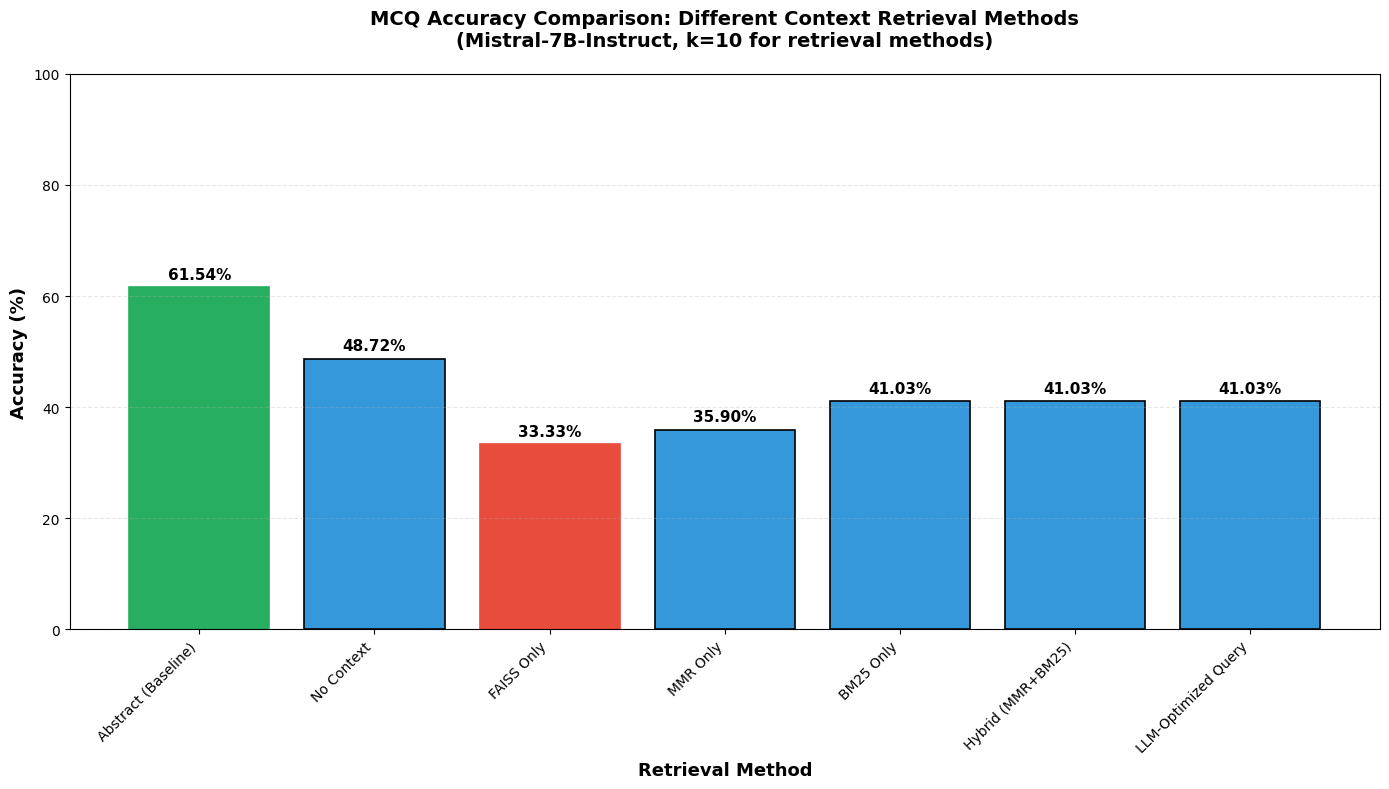

✓ Comparison chart saved!


In [19]:
# Create bar chart comparison
plt.figure(figsize=(14, 8))
methods = list(comparison_results.keys())
accuracies = list(comparison_results.values())

# Create bars with different colors
colors = ['#2ecc71' if method == 'Abstract (Baseline)' else '#3498db' for method in methods]
bars = plt.bar(methods, accuracies, color=colors, edgecolor='black', linewidth=1.2)

# Highlight best and worst
best_idx = accuracies.index(max(accuracies))
worst_idx = accuracies.index(min(accuracies))
bars[best_idx].set_color('#27ae60')
bars[worst_idx].set_color('#e74c3c')

# Add value labels on bars
for i, (method, acc) in enumerate(zip(methods, accuracies)):
    plt.text(i, acc + 1, f'{acc:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xlabel('Retrieval Method', fontsize=13, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=13, fontweight='bold')
plt.title('MCQ Accuracy Comparison: Different Context Retrieval Methods\n(Mistral-7B-Instruct, k=10 for retrieval methods)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(f'accuracy_comparison_{datetime.now().strftime("%Y%m%d_%H%M%S")}.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Comparison chart saved!")

In [20]:
# Save comprehensive JSON results
comprehensive_results = {
    'metadata': {
        'model': 'mistralai/Mistral-7B-Instruct-v0.1',
        'test_set': 'questionbank(unedited).xlsx - Synthesis sheet',
        'total_questions': len(synthesis_df),
        'retrieval_k': 10,
        'timestamp': datetime.now().strftime('%Y%m%d_%H%M%S')
    },
    'accuracy_summary': comparison_results,
    'detailed_results': {
        'abstract_baseline': results,
        'no_context': results_no_context,
        'faiss_only': results_faiss,
        'mmr_only': results_mmr,
        'bm25_only': results_bm25,
        'hybrid': results_hybrid,
        'llm_optimized_query': results_optimized
    }
}

# Save to JSON
output_filename = f"comprehensive_evaluation_results_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
with open(output_filename, 'w') as f:
    json.dump(comprehensive_results, f, indent=2)

print(f"\n✓ Comprehensive results saved to: {output_filename}")
print(f"  - Summary statistics")
print(f"  - Detailed results for all {len(synthesis_df)} questions across all 7 methods")
print(f"  - Optimized queries (for LLM-optimized method)")
print(f"  - Model responses and explanations")


✓ Comprehensive results saved to: comprehensive_evaluation_results_20260213_155258.json
  - Summary statistics
  - Detailed results for all 39 questions across all 7 methods
  - Optimized queries (for LLM-optimized method)
  - Model responses and explanations
